# Generate Segmentation Masks for Classification Dataset
This notebook loads the trained DeepLabV3 model and generates segmentation masks for half of the classification dataset.

In [1]:
# Import libraries
from pathlib import Path
from typing import Dict, List
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.transforms import InterpolationMode

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Using device: {device}")

Using device: mps


In [5]:
# Configuration
project_root = Path("/Volumes/T7/largeProject_copy")
data_root =  project_root / "dataset" / "classification"
model_path = project_root / "trained_models" / "deeplabv3_best.pt"
output_dir = project_root / "generated_masks"

# Dataset paths
train_dir = data_root / "train"
val_dir = data_root / "val"
test_dir = data_root / "test"

train_img_dir = train_dir / "input"
val_img_dir = val_dir / "input"
test_img_dir = test_dir / "input"

train_csv = train_dir / "ground_truth" / "ISIC2018_Task3_Training_GroundTruth.csv"
val_csv = val_dir / "ground_truth" / "ISIC2018_Task3_Validation_GroundTruth.csv"
test_csv = test_dir / "ground_truth" / "ISIC2018_Task3_Test_GroundTruth.csv"

# Create output directory
output_dir.mkdir(parents=True, exist_ok=True)

# Parameters
image_size = 256
batch_size = 8
num_classes = 2  # background and lesion

print(f"Model path: {model_path}")
print(f"Output directory: {output_dir}")
print(f"Data root: {data_root}")

Model path: /Volumes/T7/largeProject_copy/trained_models/deeplabv3_best.pt
Output directory: /Volumes/T7/largeProject_copy/generated_masks
Data root: /Volumes/T7/largeProject_copy/dataset/classification


In [6]:
# Dataset for classification images
class ClassificationImageDataset(Dataset):
    """Dataset for loading classification images to generate masks."""
    
    def __init__(self, image_dir: Path, image_ids: List[str], image_size: int = 256):
        self.image_dir = image_dir
        self.image_ids = image_ids
        self.image_size = image_size
        
        # ImageNet normalization
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self) -> int:
        return len(self.image_ids)
    
    def __getitem__(self, idx: int) -> Dict[str, any]:
        image_id = self.image_ids[idx]
        image_path = self.image_dir / f"{image_id}.jpg"
        
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        # Load and transform image
        image = Image.open(image_path).convert("RGB")
        original_size = image.size  # (width, height)
        image_tensor = self.transform(image)
        
        return {
            "image": image_tensor,
            "image_id": image_id,
            "original_size": original_size
        }

print("Dataset class defined.")

Dataset class defined.


In [7]:
# Load model checkpoint
print(f"Loading model from {model_path}...")
checkpoint = torch.load(model_path, map_location=device)

# Check available keys in checkpoint
print(f"Checkpoint keys: {checkpoint.keys()}")

# Reconstruct model - first create base model
model = deeplabv3_resnet50(weights=None, num_classes=num_classes)

# Get state_dict from checkpoint - handle different formats
if 'model' in checkpoint:
    state_dict = checkpoint['model']
elif 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
elif 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    # Checkpoint might be the state_dict directly
    state_dict = checkpoint

# Load weights with strict=False to ignore aux_classifier mismatches
model.load_state_dict(state_dict, strict=False)

model = model.to(device)
model.eval()

print(f"Model loaded successfully!")
print(f"Model was trained for {checkpoint.get('epoch', 'unknown')} epochs")
if 'best_dice' in checkpoint:
    print(f"Best Dice score: {checkpoint['best_dice']:.4f}")

Loading model from /Volumes/T7/largeProject_copy/trained_models/deeplabv3_best.pt...
Checkpoint keys: dict_keys(['model_state_dict', 'val_mIoU', 'val_dice', 'epoch', 'classes', 'image_size', 'per_class_iou'])
Model loaded successfully!
Model was trained for 25 epochs


In [8]:
# Collect all classification images (train + val + test)
all_image_ids = []
splits_info = {}

for split_name, csv_path, img_dir in [
    ("train", train_csv, train_img_dir),
    ("val", val_csv, val_img_dir),
    ("test", test_csv, test_img_dir)
]:
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        image_ids = df["image"].tolist()
        splits_info[split_name] = {
            "image_ids": image_ids,
            "img_dir": img_dir,
            "count": len(image_ids)
        }
        all_image_ids.extend(image_ids)
        print(f"{split_name}: {len(image_ids)} images")

print(f"\nTotal images across all splits: {len(all_image_ids)}")

selected_image_ids = all_image_ids

print(f"Generating masks for {len(selected_image_ids)} images (whole dataset)")

train: 8161 images
val: 1773 images
test: 1786 images

Total images across all splits: 11720
Generating masks for 11720 images (whole dataset)


In [9]:
# Function to determine which split an image belongs to
def get_image_split(image_id: str, splits_info: Dict) -> tuple:
    """Returns (split_name, img_dir) for a given image_id."""
    for split_name, info in splits_info.items():
        if image_id in info["image_ids"]:
            return split_name, info["img_dir"]
    return None, None

# Organize selected images by split
selected_by_split = {"train": [], "val": [], "test": []}
for image_id in selected_image_ids:
    split_name, img_dir = get_image_split(image_id, splits_info)
    if split_name:
        selected_by_split[split_name].append(image_id)

print("Images per split:")
for split_name, ids in selected_by_split.items():
    print(f"  {split_name}: {len(ids)} images")

Images per split:
  train: 8161 images
  val: 1773 images
  test: 1786 images


In [10]:
# Generate masks for each split
@torch.no_grad()
def generate_masks_for_split(model, image_ids, img_dir, split_name, output_subdir):
    """Generate segmentation masks for a list of images."""
    
    # Create output directory for this split
    split_output_dir = output_dir / output_subdir
    split_output_dir.mkdir(parents=True, exist_ok=True)
    
    # Create dataset and dataloader
    dataset = ClassificationImageDataset(img_dir, image_ids, image_size=image_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    generated_count = 0
    
    print(f"\nGenerating masks for {split_name} split...")
    for batch in tqdm(dataloader, desc=f"Processing {split_name}"):
        images = batch["image"].to(device)
        image_ids_batch = batch["image_id"]
        original_sizes = batch["original_size"]
        
        # Forward pass
        outputs = model(images)
        predictions = outputs["out"]  # Shape: (batch, num_classes, H, W)
        
        # Get predicted masks (argmax over classes)
        pred_masks = predictions.argmax(dim=1)  # Shape: (batch, H, W)
        
        # Save masks
        for i in range(len(image_ids_batch)):
            image_id = image_ids_batch[i]
            mask = pred_masks[i].cpu().numpy().astype(np.uint8)
            
            # Convert to PIL image (0 = background, 1 = lesion -> scale to 0, 255)
            mask_pil = Image.fromarray(mask * 255, mode='L')
            
            # Resize to original image size
            original_width, original_height = original_sizes[0][i].item(), original_sizes[1][i].item()
            mask_pil = mask_pil.resize((original_width, original_height), resample=Image.NEAREST)
            
            # Save mask
            mask_path = split_output_dir / f"{image_id}_segmentation.png"
            mask_pil.save(mask_path)
            generated_count += 1
    
    print(f"✓ Generated {generated_count} masks for {split_name}")
    return generated_count

print("Mask generation function defined.")

Mask generation function defined.


In [11]:
# Generate masks for all selected images
total_generated = 0

for split_name in ["train", "val", "test"]:
    if selected_by_split[split_name]:
        count = generate_masks_for_split(
            model=model,
            image_ids=selected_by_split[split_name],
            img_dir=splits_info[split_name]["img_dir"],
            split_name=split_name,
            output_subdir=split_name
        )
        total_generated += count

print(f"\n{'='*60}")
print(f"✓ Total masks generated: {total_generated}")
print(f"✓ Output directory: {output_dir}")
print(f"{'='*60}")


Generating masks for train split...


Processing train: 100%|██████████| 1021/1021 [14:28<00:00,  1.17it/s]


✓ Generated 8161 masks for train

Generating masks for val split...


Processing val: 100%|██████████| 222/222 [03:26<00:00,  1.08it/s]


✓ Generated 1773 masks for val

Generating masks for test split...


Processing test: 100%|██████████| 224/224 [03:23<00:00,  1.10it/s]

✓ Generated 1786 masks for test

✓ Total masks generated: 11720
✓ Output directory: /Volumes/T7/largeProject_copy/generated_masks


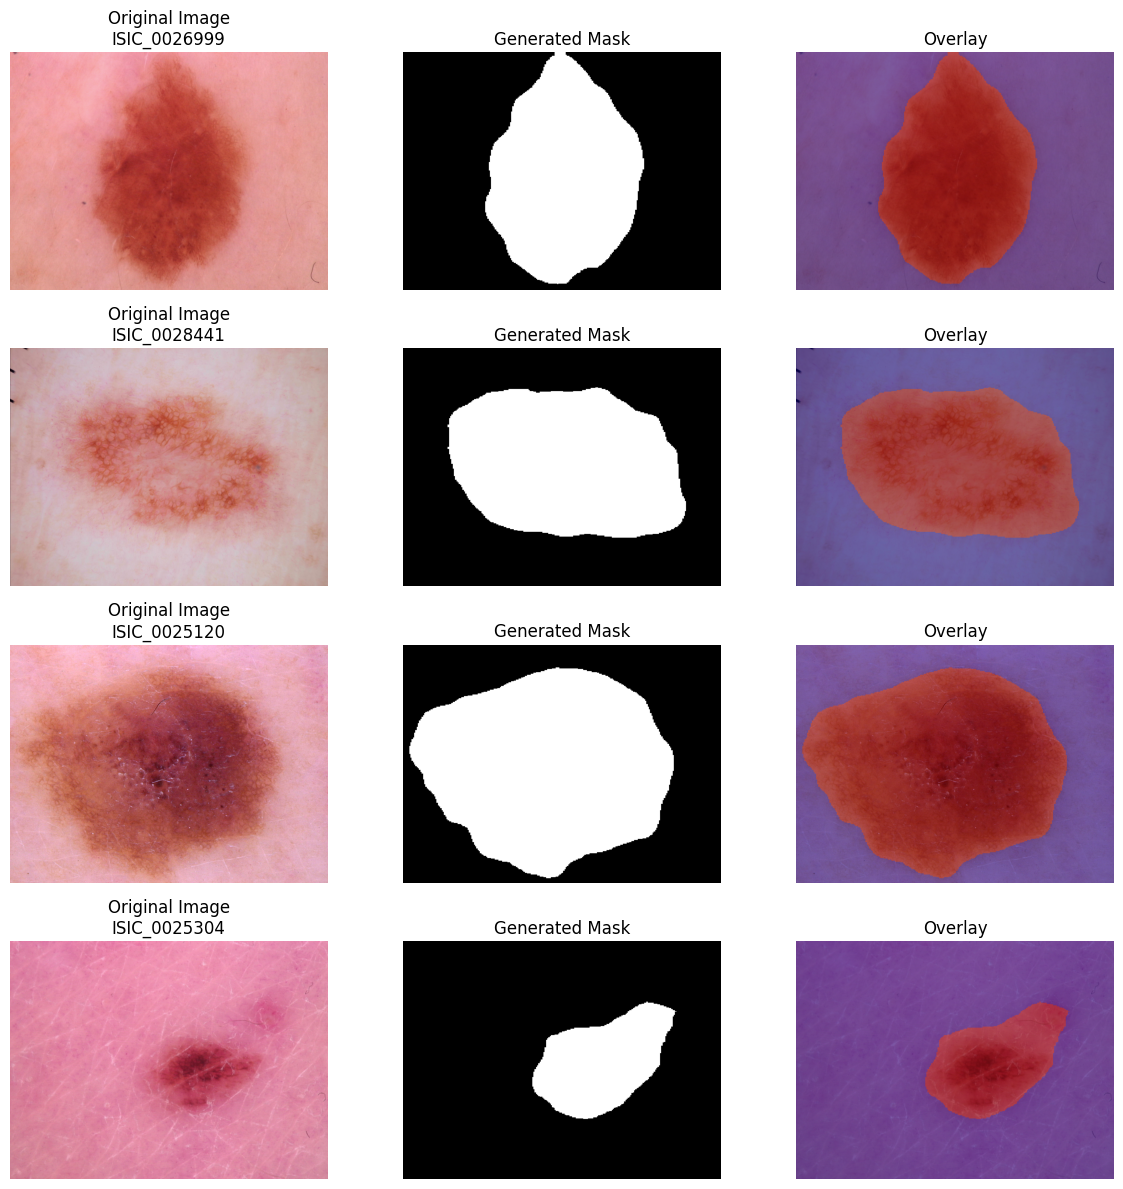

In [12]:
# Visualize some generated masks
import matplotlib.pyplot as plt
import random

def visualize_masks(num_samples: int = 4):
    """Visualize some generated masks alongside original images."""
    
    # Randomly select some images from the generated masks
    sample_image_ids = random.sample(selected_image_ids, min(num_samples, len(selected_image_ids)))
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 3))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, image_id in enumerate(sample_image_ids):
        split_name, img_dir = get_image_split(image_id, splits_info)
        
        # Load original image
        img_path = img_dir / f"{image_id}.jpg"
        image = Image.open(img_path).convert("RGB")
        
        # Load generated mask
        mask_path = output_dir / split_name / f"{image_id}_segmentation.png"
        mask = Image.open(mask_path).convert("L")
        
        # Plot
        axes[idx, 0].imshow(image)
        axes[idx, 0].set_title(f"Original Image\n{image_id}")
        axes[idx, 0].axis("off")
        
        axes[idx, 1].imshow(mask, cmap="gray")
        axes[idx, 1].set_title("Generated Mask")
        axes[idx, 1].axis("off")
        
        # Overlay
        axes[idx, 2].imshow(image)
        axes[idx, 2].imshow(mask, alpha=0.5, cmap="jet")
        axes[idx, 2].set_title("Overlay")
        axes[idx, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

# Visualize 4 random samples
visualize_masks(num_samples=4)